# Shared variance: cognitive parameters vs. symptom surveys — a CCA ladder with SHARP inference

**Question.** How much shared variance between the fitted cognitive-task parameters and the symptom surveys generalizes to held-out subjects, and does added model flexibility help?

**Ladder of methods** (least → most flexible), 7 arms:
- `raw` — regularized linear CCA on standardized raw features, each view PCA-reduced to 10 components first (baseline)
- `kernel` — kernel CCA (RBF) directly (KCCA; not a linear CCA on top)
- `deep` — Deep CCA (trained MLP encoders) + linear CCA on the learned representations
- `fm` — frozen TabPFN v2 embeddings + linear CCA
- `fm_deep` — TabPFN fine-tuned jointly with a deep CCA head, then linear CCA
- `tabfm` — frozen Google TabFM embeddings + linear CCA
- `tabfm_deep` — TabFM fine-tuned jointly with a deep CCA head, then linear CCA

The `deep`/`fm`/`tabfm`/`fm_deep`/`tabfm_deep` arms end in a linear CCA so canonical dimensions are ordered; the `kernel` arm uses KCCA directly. Held-out canonical correlations are **signed** (a joint sign flip of both variates preserves r, so a negative held-out r means the fitted direction did not generalize — it is *not* folded to |r|).

**Cohort.** Training half only, with the model-fit convergence exclusion (`max_rhat>1.1` on any task) — **N=1298**, the same cohort as the Anna Karenina and XGBoost analyses.

**Inference — SHARP test (paper-faithful).** CV fold statistics are not independent, so naive CIs / repeated-split intervals inflate false positives (Zeng et al. 2026, bioRxiv 2026.05.17.724301). SHARP splits subjects into two **disjoint** halves per repetition (stratified by `backfilled_prolific_screen_group`), runs K-fold CV within each, and uses the within-repetition independence of the halves to identify σ² and ρ. Inference is the paper's **null-constrained score test** with **test-inversion** 95% CIs (not the earlier method-of-moments + Wald, which inflated the FPR). A within-strata permutation null gives the above-chance test.

**Compute.** `scripts/run_sharp_ladder.py` (multi-GPU via `cogmood_analysis.sharp_parallel`) checkpoints `data/exploratory/sharp_ladder_results_rhat1p1.pkl`; this notebook loads and visualizes it.

```
SV_MAX_RHAT=1.1 uv run python scripts/run_sharp_ladder.py   # N=1298 full run (all GPUs)
```

In [1]:
import pickle
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
# N=1298 cohort (max_rhat>1.1 excluded) -- matches the AK / XGBoost analyses.
RESULTS = Path("../data/exploratory/sharp_ladder_results_rhat1p1.pkl")
R = pickle.loads(RESULTS.read_bytes())
ARMS = R["arms"]
PERM_DONE = [a for a in ARMS if a in R["perms"]]
print(("QUICK" if R["quick"] else "FULL"), f"run | N={R['n_subjects']} | J={R['J']} K={R['K']}")
print("permutations per arm:", R["n_perm"])
print("permutation nulls available for:", PERM_DONE)
print(f"View A (cognitive): {len(R['a_columns'])} cols | View B (symptom): {len(R['b_columns'])} cols")
prov = R.get("provenance")
if prov:
    print(f"provenance: commit={str(prov.get('source_commit'))[:9]} dirty={prov.get('dirty')} "
          f"| training_csv={prov.get('training_csv_sha256','')[:12]} "
          f"| subject_set={prov.get('subject_set_sha256','')[:12]}")

FULL run | N=1298 | J=30 K=5
permutations per arm: {'raw': 1000, 'kernel': 1000, 'deep': 100, 'fm': 100, 'fm_deep': 50, 'tabfm': 100, 'tabfm_deep': 50}
permutation nulls available for: ['raw', 'kernel', 'deep', 'fm', 'fm_deep', 'tabfm', 'tabfm_deep']
View A (cognitive): 30 cols | View B (symptom): 20 cols
provenance: commit=509551e2b dirty=True | training_csv=e86542ef6b31 | subject_set=7c7f63c41674


## 1. Per-arm held-out canonical correlation with valid SHARP 95% CIs

In [2]:
cis, perms = R["cis"], R["perms"]
print(f"{'arm':8s} {'held-out r':>11s} {'95% CI':>20s} {'shared var':>11s} {'rho':>6s} {'p_perm':>8s}")
for a in ARMS:
    c = cis[a]
    pp = f"{perms[a]['p']:.4f}" if a in perms else "   --"
    print(f"{a:8s} {c['mean']:>11.3f}  [{c['lo']:+.3f},{c['hi']:+.3f}] {c['shared_variance']:>11.4f} {c['rho']:>6.2f} {pp:>8s}")

arm       held-out r               95% CI  shared var    rho   p_perm
raw            0.080  [-0.005,+0.164]      0.0064   0.39   0.0090
kernel         0.088  [+0.018,+0.158]      0.0078   0.28   0.0100
deep           0.049  [+0.005,+0.092]      0.0024   0.17   0.0396
fm            -0.010  [-0.050,+0.030]      0.0001   0.03   0.1584
fm_deep       -0.005  [-0.051,+0.042]      0.0000   0.00   0.7451
tabfm          0.063  [+0.000,+0.125]      0.0039   0.29   0.0099
tabfm_deep       0.044  [-0.027,+0.115]      0.0020   0.25   0.0196


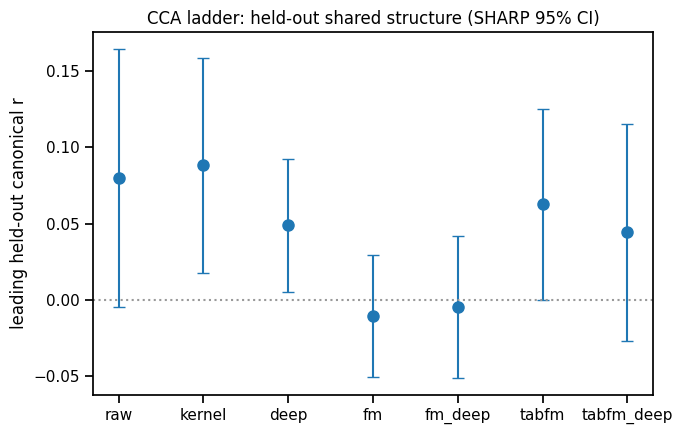

In [3]:
# Ladder plot: leading held-out canonical r with SHARP 95% CI
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(ARMS))
means = [cis[a]['mean'] for a in ARMS]
los = [cis[a]['mean'] - cis[a]['lo'] for a in ARMS]
his = [cis[a]['hi'] - cis[a]['mean'] for a in ARMS]
ax.errorbar(x, means, yerr=[los, his], fmt='o', capsize=4, ms=8, color='C0')
ax.axhline(0, ls=':', color='0.6')
ax.set_xticks(x); ax.set_xticklabels(ARMS)
ax.set_ylabel('leading held-out canonical r')
ax.set_title('CCA ladder: held-out shared structure (SHARP 95% CI)')
plt.tight_layout(); plt.show()

## 2. Pairwise SHARP comparisons (which rung wins?)

Paper-faithful score test on the paired per-half difference in held-out canonical r (fold-dependence-aware). There are C(7,2)=21 pairwise tests, so a Benjamini–Hochberg FDR q-value across the family is reported alongside the raw p.

comparison                 diff       z        p     q_BH
raw vs kernel            -0.008   -0.23   0.8210   0.8210
raw vs deep              +0.031   +1.65   0.0983   0.2063
raw vs fm                +0.090   +1.94   0.0520   0.2063
raw vs fm_deep           +0.085   +1.68   0.0939   0.2063
raw vs tabfm             +0.017   +0.62   0.5379   0.5946
raw vs tabfm_deep        +0.036   +1.16   0.2475   0.3466
kernel vs deep           +0.039   +1.20   0.2319   0.3466
kernel vs fm             +0.098   +2.40   0.0165   0.2063
kernel vs fm_deep        +0.093   +1.99   0.0463   0.2063
kernel vs tabfm          +0.025   +0.74   0.4620   0.5390
kernel vs tabfm_deep     +0.044   +1.42   0.1550   0.2958
deep vs fm               +0.059   +2.09   0.0363   0.2063
deep vs fm_deep          +0.053   +1.81   0.0702   0.2063
deep vs tabfm            -0.014   -1.11   0.2691   0.3532
deep vs tabfm_deep       +0.004   +0.99   0.3212   0.3968
fm vs fm_deep            -0.006   -0.23   0.8166   0.8210
fm vs tabfm   

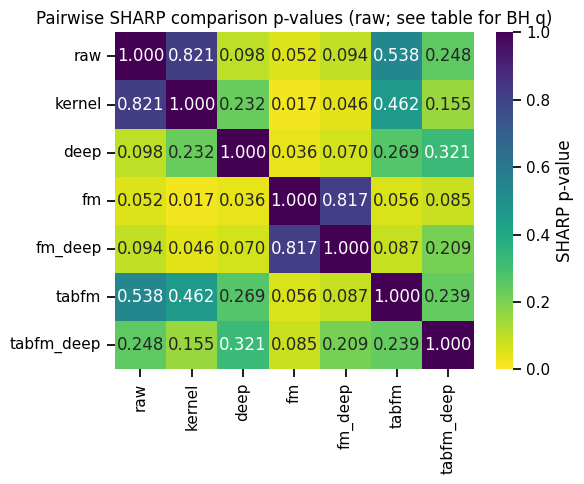

In [4]:
comparisons = R["comparisons"]

def _bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = np.empty(n); prev = 1.0
    for rank, i in enumerate(order[::-1]):
        prev = min(prev, p[i] * n / (n - rank)); q[i] = prev
    return q

pairs = list(itertools.combinations(ARMS, 2))
praw = np.array([comparisons[f"{a1}_vs_{a2}"]["p"] for a1, a2 in pairs])
qvals = _bh_fdr(praw)
print(f"{'comparison':22s} {'diff':>8s} {'z':>7s} {'p':>8s} {'q_BH':>8s}")
for (a1, a2), q in zip(pairs, qvals):
    c = comparisons[f"{a1}_vs_{a2}"]
    print(f"{a1+' vs '+a2:22s} {c['diff']:>+8.3f} {c['z']:>+7.2f} {c['p']:>8.4f} {q:>8.4f}")
print(f"\nPairwise comparisons surviving BH-FDR (q<0.05): {int((qvals<0.05).sum())} / {len(pairs)}")

P = np.ones((len(ARMS), len(ARMS)))
for (a1, a2) in pairs:
    c = comparisons[f"{a1}_vs_{a2}"]
    i, j = ARMS.index(a1), ARMS.index(a2)
    P[i, j] = P[j, i] = c['p']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(P, annot=True, fmt='.3f', xticklabels=ARMS, yticklabels=ARMS,
            cmap='viridis_r', vmin=0, vmax=1, cbar_kws={'label': 'SHARP p-value'}, ax=ax)
ax.set_title('Pairwise SHARP comparison p-values (raw; see table for BH q)')
plt.tight_layout(); plt.show()

## 3. Above-chance test: within-strata permutation null

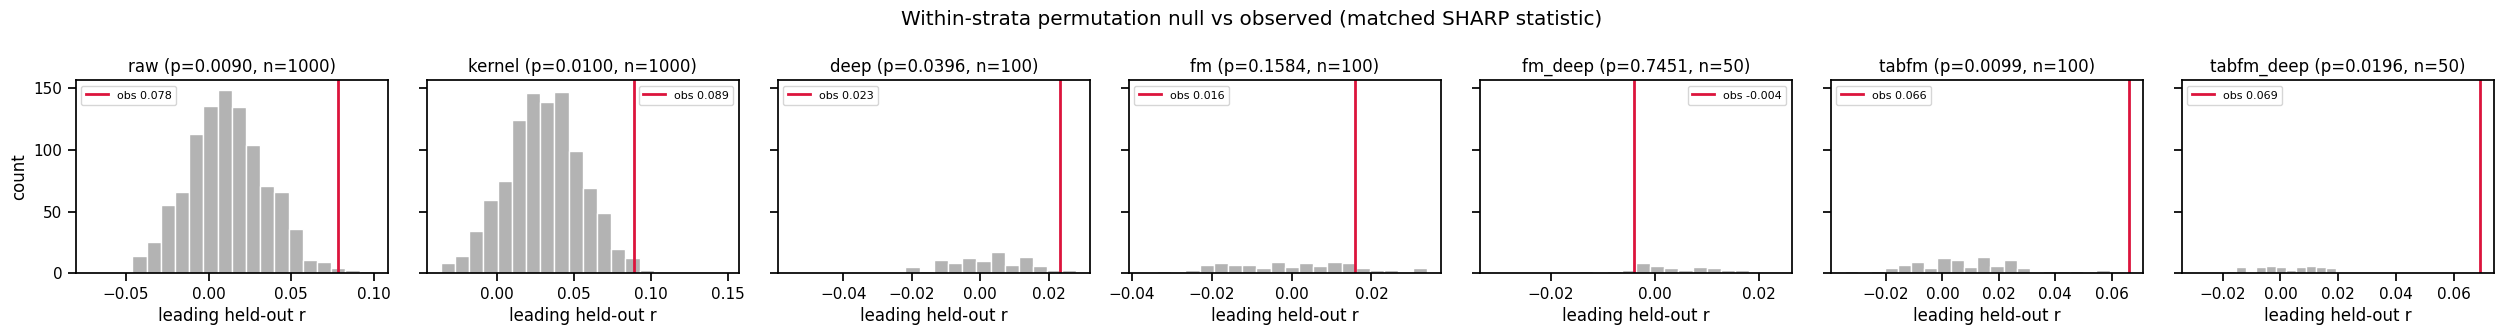

In [5]:
if PERM_DONE:
    fig, axes = plt.subplots(1, len(PERM_DONE), figsize=(3.6 * len(PERM_DONE), 3.4), sharey=True)
    if len(PERM_DONE) == 1:
        axes = [axes]
    for ax, a in zip(axes, PERM_DONE):
        out = perms[a]
        ax.hist(out['null'], bins=20, color='0.7', edgecolor='white')
        ax.axvline(out['observed'], color='crimson', lw=2, label=f"obs {out['observed']:.3f}")
        ax.set_title(f"{a} (p={out['p']:.4f}, n={R['n_perm'][a]})")
        ax.set_xlabel('leading held-out r'); ax.legend(fontsize=8)
    axes[0].set_ylabel('count')
    plt.suptitle('Within-strata permutation null vs observed (matched SHARP statistic)')
    plt.tight_layout(); plt.show()
else:
    print('No permutation nulls in the results file yet.')

## 4. Summary

Read off the tables/plots above:
- **Per-arm** held-out **leading** canonical r with **SHARP 95% CI** (score-test inversion), the implied **leading-dimension** shared variance (r² of the top canonical pair — *not* total multivariate shared variance), and the within-strata permutation p.
- **Pairwise** SHARP score tests (BH-FDR across the 21 comparisons): whether any flexible arm beats the linear `raw` baseline — i.e. whether nonlinearity / a foundation model raises the *generalizable* ceiling.

**Reporting language.** Estimates are *generalizable* (held-out), **signed** leading canonical correlations with valid SHARP uncertainty (null-constrained score test + test-inversion CIs); naive across-fold/repeated-split CIs and the earlier method-of-moments+Wald test are invalid/miscalibrated and not used (Zeng et al. 2026). "Shared variance" here is the squared **leading** canonical correlation, a lower-dimensional summary, not the total shared variance across all canonical dimensions. The ladder brackets the achievable ceiling under linear, kernel, deep, and two foundation-model families; the maximum across rungs is a model/representation-conditional estimate, not an absolute maximum. Cohort: training half, `max_rhat>1.1` excluded (N=1298), stratified by `backfilled_prolific_screen_group`. Foundation-model arms carry a within-view support/query caveat (see `embed_view_fm`).